In [105]:
import pandas as pd
# import dask.dataframe as dd
from csv import QUOTE_NONNUMERIC
import matplotlib.dates as mdates
from datetime import datetime
import seaborn as sns
from matplotlib import colors, cm
import matplotlib.ticker
import matplotlib.pyplot as plt
#     "sns.set_theme(style=\"darkgrid\")\n",
plt.rcParams['svg.fonttype'] = 'none'
import locale

In [107]:
locale.setlocale(locale.LC_TIME, "uk_UA.UTF-8")

'uk_UA.UTF-8'

In [ ]:
!pip install dask

In [ ]:
def store_csv(df, csv_name: str=None, index=None,
              index_label=None):
    """
    If `index` is not set, it means to True.
    :param df: Dataframe to export as CSV
    :param csv_name: Name of resulting CSV file
    :param index: store index in CSV file
    :return: None
    """
    csv_name = csv_name.strip()
    if index is None:
        index = True
    df.to_csv(csv_name, sep='\t', na_rep='', float_format=None, columns=None,
              header=True, index=index, index_label=None, mode='w',
              encoding=None, compression='infer', quoting=2,
              quotechar='"', line_terminator='\n', chunksize=None,
              date_format=None, doublequote=True, escapechar=None, decimal='.')

In [2]:
dtype = {k: "str" for k in (
    "region_id", "kekv", "kpk", "contractId", 'payer_edrpou', 'recipt_edrpou',
    "contractNumber", "budgetCode", 'payer_mfo', 'recipt_mfo', 'doc_vob', 'doc_number',
)} | {k: "int64" for k in ('id',)} | {'doc_vob_name': 'object',
       'payer_bank': 'object',
       'recipt_bank': 'object'}

In [71]:
dtype

{'region_id': 'str',
 'kekv': 'str',
 'kpk': 'str',
 'contractId': 'str',
 'payer_edrpou': 'str',
 'recipt_edrpou': 'str',
 'contractNumber': 'str',
 'budgetCode': 'str',
 'payer_mfo': 'str',
 'recipt_mfo': 'str',
 'doc_vob': 'str',
 'doc_number': 'str',
 'id': 'int64',
 'doc_vob_name': 'object',
 'payer_bank': 'object',
 'recipt_bank': 'object'}

In [ ]:
df = pd.read_csv("data.csv", sep="\t",
            dtype=dtype, low_memory=False, blocksize="248MB")
# df.columns = df.iloc[0].tolist()
# df.drop(0, inplace=True)

In [ ]:
df.sample(frac=3.14, replace=None)

In [ ]:
df.to_hdf("/Volumes/Passport/new.hd5", "data", format="table")

In [ ]:
df.to_parquet("data.parquet")

In [ ]:
edr = pd.read_csv("/Users/rino/dev/userou/edr/h_edr_data.csv", sep=",",
            dtype={"Edr": "str", "PostalCode": "str"})
edr.rename(
    {"Edr":"payer_edrpou"}, axis=1, inplace=True)

In [ ]:
edr.sample()

In [ ]:
dfdf['payer_edrpou'].isin(edr.Edr.unique())

In [ ]:
k = df.sample(frac=1)

In [ ]:
k.compute()

In [74]:
df.sample(5)

,id,doc_vob,doc_vob_name,doc_number,doc_date,doc_v_date,trans_date,amount,amount_cop,currency,...,region_id,payment_type,payment_data,source_id,source_name,kekv,kpk,contractId,contractNumber,budgetCode
5085119,231435375,1,NaN,37,2022-04-01,2022-04-04,2022-04-04,128.02,12802,UAH,...,10,nsep,NaN,2,ДКСУ,2111.0,1115033.0,NaN,NaN,1010000000.0
5688864,232063985,1,NaN,883,2022-04-18,2022-04-18,2022-04-19,3894.13,389413,UAH,...,15,nsep,NaN,2,ДКСУ,NaN,0.0,NaN,NaN,9900000000.0
691562,226445179,1,NaN,18422,2022-01-18,2022-01-20,2022-01-21,1191.60,119160,UAH,...,16,nsep,NaN,2,ДКСУ,NaN,0000000,NaN,NaN,9900000000
6662721,233079003,1,NaN,190,2022-05-12,2022-05-12,2022-05-13,2000.00,200000,UAH,...,19,nsep,NaN,2,ДКСУ,2111.0,611010.0,NaN,NaN,1953800000.0
382100,226200048,1,NaN,1,2022-01-17,2022-01-18,2022-01-18,17500.00,1750000,UAH,...,13,nsep,NaN,2,ДКСУ,2111,1014040,NaN,NaN,1357700000


In [85]:
df.loc[5741127]

id                                                         232244427
doc_vob                                                            1
doc_vob_name                                                     NaN
doc_number                                                        15
doc_date                                                  0320-04-20
doc_v_date                                                2022-04-20
trans_date                                                2022-04-21
amount                                                         552.0
amount_cop                                                     55200
currency                                                         UAH
payer_edrpou                                                00698874
payer_name                                           МіжгірськаРДЛВМ
payer_account                          UA728201720343111001200010409
payer_mfo                                                        NaN
payer_bank                        

In [3]:
chunksize = 10 ** 6
box = []
c = 1
with pd.read_csv("data.csv", sep="\t",
                 chunksize=chunksize, dtype=dtype, low_memory=False) as reader:
    for chunk in reader:
        print(c, end=",")
        box.append(chunk)
        c+=1
df = pd.concat(box)

1,2,3,4,5,6,7,8,9,10,11,

In [17]:
for t in df.groupby([pd.to_datetime(df['trans_date']).dt.year,
                     pd.to_datetime(df['trans_date']).dt.month]):
#     print(t)
#     break
#     mon = pd.to_datetime(t[1].iloc[0].doc_date).month
    t[1].to_parquet(f"{t[0][0]}{str(t[0][1]).zfill(2)}.parquet")

In [20]:
for f in [f"2022{str(x).zfill(2)}" for x in range(1,8)]:
    _ = pd.read_parquet(f + ".parquet")
    _.to_csv(f+".csv", sep='\t', na_rep='', float_format=None, columns=None,
              header=True, index=False, mode='w',
              encoding="cp1251", compression='infer', quoting=2,
              quotechar='"', line_terminator='\n', chunksize=None,
              date_format=None, doublequote=True, escapechar=None, decimal='.')

In [8]:
df.loc[df[df.doc_date=="0320-04-20"].index.to_list(), 'doc_date']  = "2022-04-20"

In [82]:
# df[df.doc_date=="0022-02-10"].index.to_list()

In [ ]:
df3 = df2[df2.OrganizationType.isin([0,140,145,160,230,231,232,400,
410,425,510,540,590,610,900,995])].copy()

In [21]:
#pd.read_parquet("202212.parquet")

In [ ]:
df3.groupby(['payer_edrpou', 'Name'], 
            as_index=False)[['amount']].sum().sort_values('amount', ascending=False).to_excel('bb.xlsx')

In [ ]:
# df['id'] = df['id'].astype("int64")
# df['doc_vob'] = df['doc_vob'].astype("str")
# df['doc_number'] = df['doc_number'].astype("str")
df[['payer_edrpou', 'recipt_edrpou']] = df[['payer_edrpou', 'recipt_edrpou']].astype('str')

In [16]:
for i in df['trans_date'].unique():
    try:
        pd.to_datetime(i)
    except:
        print(i)
        raise

In [ ]:
df.shape

In [ ]:
del df['id']

In [ ]:
df3[df3.payer_edrpou.isin(['00037256', '19122935'])].to_excel("bb2.xlsx")

In [ ]:
store_csv(
    df,
    "data.csv", index=False)

In [ ]:
df.columns

In [ ]:
df.to_parquet("data.parquet", engine="fastparquet")

### Awards

In [11]:
%ls *.parquet

202201.parquet  202203.parquet  202205.parquet  202207.parquet
202202.parquet  202204.parquet  202206.parquet


In [12]:
box = []
for i in ['202201.parquet','202203.parquet','202205.parquet','202207.parquet',
          '202202.parquet','202204.parquet','202206.parquet']:
    _ = pd.read_parquet(i)
    box.append(_[_.recipt_edrpou=='21575489'].copy())

In [15]:
df = pd.concat(box)

In [23]:
edr[edr.Edr.isin(df.payer_edrpou.unique())]

,Edr,Name,ShortName,OrganizationType,PostalCode,Address,FormattedAddress,Region,LocalityType,Locality,StreetType,Street,Building,BuildingType,Structure,StructureType,Apartment,ApartmentType,Status,RegDate
103,00019413,КОМІТЕТ З ДЕРЖАВНИХ ПРЕМІЙ УКРАЇНИ В ГАЛУЗІ НА...,КОМІТЕТ З ДЕРЖПРЕМІЙ УКРАЇНИ,425,3150.0,"М. КИЇВ, ВУЛ. МАЛЕВИЧА КАЗИМИРА, БУД. 11","03150, місто КИЇВ, вулиця МАЛЕВИЧА КАЗИМИРА, б...",NaN,місто,КИЇВ,вулиця,МАЛЕВИЧА КАЗИМИРА,11,будинок,NaN,NaN,NaN,NaN,registered,2000-06-14 00:00:00
200,00037256,ДЕРЖАВНЕ УПРАВЛІННЯ СПРАВАМИ,ДЕРЖАВНЕ УПРАВЛІННЯ СПРАВАМИ,425,1220.0,"М. КИЇВ, ВУЛ. БАНКОВА, БУД. 11","01024, місто КИЇВ, вулиця БАНКОВА, будинок 11",NaN,місто,КИЇВ,вулиця,БАНКОВА,11,будинок,NaN,NaN,NaN,NaN,registered,2000-03-21 00:00:00
1225349,37501611,УПРАВЛІННЯ СОЦІАЛЬНОГО ЗАХИСТУ НАСЕЛЕННЯ ДЕСНЯ...,УСЗН ДЕСНЯНСЬКОЇ РДА В МІСТІ КИЄВІ,410,2232.0,"М. КИЇВ, ВУЛ. ЗАКРЕВСЬКОГО, БУД. 87-Д","02232, місто КИЇВ, вулиця ЗАКРЕВСЬКОГО, будино...",NaN,місто,КИЇВ,вулиця,ЗАКРЕВСЬКОГО,87-Д,будинок,NaN,NaN,NaN,NaN,registered,2011-01-05 00:00:00
1604560,41420759,ЛІВОБЕРЕЖНЕ ВІДДІЛЕННЯ УПРАВЛІННЯ ВИКОНАВЧОЇ Д...,NaN,610,2094.0,"М. КИЇВ, ВУЛ. ПОПУДРЕНКА, БУД. 34","02100, місто КИЇВ, вулиця ПОПУДРЕНКА, будинок 34",NaN,місто,КИЇВ,вулиця,ПОПУДРЕНКА,34,будинок,NaN,NaN,NaN,NaN,registered,1970-01-01 03:00:00


In [26]:
edr.iloc[103].Name

'КОМІТЕТ З ДЕРЖАВНИХ ПРЕМІЙ УКРАЇНИ В ГАЛУЗІ НАУКИ І ТЕХНІКИ'

In [21]:
edr = pd.read_csv("/Users/rino/dev/userou/edr/h_edr_data.csv", dtype={"Edr": "str"})

In [30]:
award = df[(df.payer_edrpou=='00037256') & (df.recipt_edrpou=='21575489')]

In [29]:
df.columns

Index(['id', 'doc_vob', 'doc_vob_name', 'doc_number', 'doc_date', 'doc_v_date',
       'trans_date', 'amount', 'amount_cop', 'currency', 'payer_edrpou',
       'payer_name', 'payer_account', 'payer_mfo', 'payer_bank',
       'recipt_edrpou', 'recipt_name', 'recipt_account', 'recipt_bank',
       'recipt_mfo', 'payment_details', 'doc_add_attr', 'region_id',
       'payment_type', 'payment_data', 'source_id', 'source_name', 'kekv',
       'kpk', 'contractId', 'contractNumber', 'budgetCode'],
      dtype='object')

In [35]:
award.groupby(
    pd.to_datetime(award['trans_date']).dt.month)[['amount']].sum()

,amount
trans_date,
5,9967390.0
6,8091300.0
7,2985011.0


In [36]:
award.amount.sum()

21043701.0

In [40]:
award.iloc[1].payment_details

'0301050;2210;Част.опл.за державні нагороди України; зг.дог.22-81-107/рвс8 від 10.05.22, акт 1/16.05.22 накл.80016119/22.04.22;В т.ч.ПДВ 199080.33.'

### 2021

In [55]:
box21 = []
for csvfile in '202101.csv 202102.csv 202103.csv 202104.csv 202105.csv 202106.csv 202107.csv'.split():
    _ = pd.read_csv(csvfile, encoding="cp1251",sep=";", skiprows=1,
            dtype={'doc_vob_name': "str",'doc_number': "str",'payer_edrpou': "str",
                   'payer_bank': "str",'recipt_bank': "str",'contractId': "str",
                   'contractNumber': "str"})
    box21.append(_[_.recipt_edrpou=='21575489'].copy())

In [57]:
df21 = pd.concat(box21)

In [170]:
edr[edr.Edr.isin(df21.payer_edrpou.unique())]
# award21 = df21[(df21.payer_edrpou=='00037256') & (df21.recipt_edrpou=='21575489')]

,Edr,Name,ShortName,OrganizationType,PostalCode,Address,FormattedAddress,Region,LocalityType,Locality,StreetType,Street,Building,BuildingType,Structure,StructureType,Apartment,ApartmentType,Status,RegDate
103,00019413,КОМІТЕТ З ДЕРЖАВНИХ ПРЕМІЙ УКРАЇНИ В ГАЛУЗІ НА...,КОМІТЕТ З ДЕРЖПРЕМІЙ УКРАЇНИ,425,3150.0,"М. КИЇВ, ВУЛ. МАЛЕВИЧА КАЗИМИРА, БУД. 11","03150, місто КИЇВ, вулиця МАЛЕВИЧА КАЗИМИРА, б...",NaN,місто,КИЇВ,вулиця,МАЛЕВИЧА КАЗИМИРА,11,будинок,NaN,NaN,NaN,NaN,registered,2000-06-14 00:00:00
200,00037256,ДЕРЖАВНЕ УПРАВЛІННЯ СПРАВАМИ,ДЕРЖАВНЕ УПРАВЛІННЯ СПРАВАМИ,425,1220.0,"М. КИЇВ, ВУЛ. БАНКОВА, БУД. 11","01024, місто КИЇВ, вулиця БАНКОВА, будинок 11",NaN,місто,КИЇВ,вулиця,БАНКОВА,11,будинок,NaN,NaN,NaN,NaN,registered,2000-03-21 00:00:00
919745,34334305,ТЕРНОПІЛЬСЬКА МІСЬКА РАДА,NaN,420,46001.0,"ТЕРНОПІЛЬСЬКА ОБЛ., М. ТЕРНОПІЛЬ, ВУЛ. ЛИСТОПА...","46001, ТЕРНОПІЛЬСЬКА область, місто ТЕРНОПІЛЬ,...",ТЕРНОПІЛЬСЬКА область,місто,ТЕРНОПІЛЬ,вулиця,ЛИСТОПАДОВА,5,будинок,NaN,NaN,NaN,NaN,registered,1990-03-26 01:00:00
1225349,37501611,УПРАВЛІННЯ СОЦІАЛЬНОГО ЗАХИСТУ НАСЕЛЕННЯ ДЕСНЯ...,УСЗН ДЕСНЯНСЬКОЇ РДА В МІСТІ КИЄВІ,410,2232.0,"М. КИЇВ, ВУЛ. ЗАКРЕВСЬКОГО, БУД. 87-Д","02232, місто КИЇВ, вулиця ЗАКРЕВСЬКОГО, будино...",NaN,місто,КИЇВ,вулиця,ЗАКРЕВСЬКОГО,87-Д,будинок,NaN,NaN,NaN,NaN,registered,2011-01-05 00:00:00
1604560,41420759,ЛІВОБЕРЕЖНЕ ВІДДІЛЕННЯ УПРАВЛІННЯ ВИКОНАВЧОЇ Д...,NaN,610,2094.0,"М. КИЇВ, ВУЛ. ПОПУДРЕНКА, БУД. 34","02100, місто КИЇВ, вулиця ПОПУДРЕНКА, будинок 34",NaN,місто,КИЇВ,вулиця,ПОПУДРЕНКА,34,будинок,NaN,NaN,NaN,NaN,registered,1970-01-01 03:00:00
1756704,42956062,РЕГІОНАЛЬНЕ ВІДДІЛЕННЯ ФОНДУ ДЕРЖАВНОГО МАЙНА ...,NaN,410,33001.0,"РІВНЕНСЬКА ОБЛ., М. РІВНЕ(З), ВУЛ. МОГИЛИ ПЕТР...","33001, РІВНЕНСЬКА область, місто РІВНЕ(З), вул...",РІВНЕНСЬКА область,місто,РІВНЕ(З),вулиця,МОГИЛИ ПЕТРА,24,будинок,NaN,NaN,NaN,NaN,registered,2019-04-16 00:00:00


In [62]:
award21.sample(2)

,id,doc_vob,doc_vob_name,doc_number,doc_date,doc_v_date,trans_date,amount,amount_cop,currency,...,region_id,payment_type,payment_data,source_id,source_name,kekv,kpk,contractId,contractNumber,budgetCode
857042,207785597,1,NaN,1080,2021-07-12,2021-07-14,2021-07-14,378412.5,37841250,UAH,...,28,nsep,NaN,2,ДКСУ,2210.0,301050.0,07b8e3dbd20340cfbdaefa7bb4748afe,UA-2021-04-01-006214-c,9.900000e+09
160502,201768372,1,NaN,654,2021-05-06,2021-05-07,2021-05-07,37980.0,3798000,UAH,...,28,nsep,NaN,2,ДКСУ,2210.0,301050.0,0c27261b869841d98c3313689d7e725b,UA-2021-04-02-000351-c,9.900000e+09


In [63]:
award.sample(2)

,id,doc_vob,doc_vob_name,doc_number,doc_date,doc_v_date,trans_date,amount,amount_cop,currency,...,region_id,payment_type,payment_data,source_id,source_name,kekv,kpk,contractId,contractNumber,budgetCode
8140396,234705961,1,None,882,2022-06-06,2022-06-06,2022-06-09,279916.2,27991620,UAH,...,28,nsep,NaN,2,ДКСУ,2210.0,301050.0,None,None,9900000000.0
10230672,237642950,1,None,1115,2022-07-04,2022-07-05,2022-07-27,1123580.0,112358000,UAH,...,28,nsep,NaN,2,ДКСУ,2210.0,301050.0,None,None,9900000000.0


In [65]:
award2122 = pd.concat([award, award21])

In [69]:
award2122 = \
award2122.groupby(
    [
        pd.to_datetime(award2122['trans_date']).dt.year,
        pd.to_datetime(award2122['trans_date']).dt.month
    ])[['amount']].sum()

In [97]:
award2122.date = award2122.apply(
    lambda x: f"{int(x.year)}-{str(int(x.mon)).zfill(2)}", axis=1)

In [92]:
award2122['mln'] = award2122.amount / 1000000

In [109]:
# award2122['year'] = award2122.index.get_level_values(0)
# award2122['mon'] = award2122.index.get_level_values(1)

# ['month'].map(str)+ '-' +df['year'].map(str)
award2122['date2'] = pd.to_datetime(award2122['date'], format='%Y-%m').dt.strftime('%b %Y')
# fig, ax = plt.subplots()
# plt.plot_date(df['date'], df['Value'])
# plt.show()

In [134]:
award2122.index.names = ['year_', 'month_']

In [135]:
award2122.groupby('year')[['mln']].sum()

,mln
year,
2021,8.909827
2022,21.043701


In [136]:
21.043701 / 8.909827

2.3618529293554182

In [113]:
plt.style.use('fivethirtyeight')

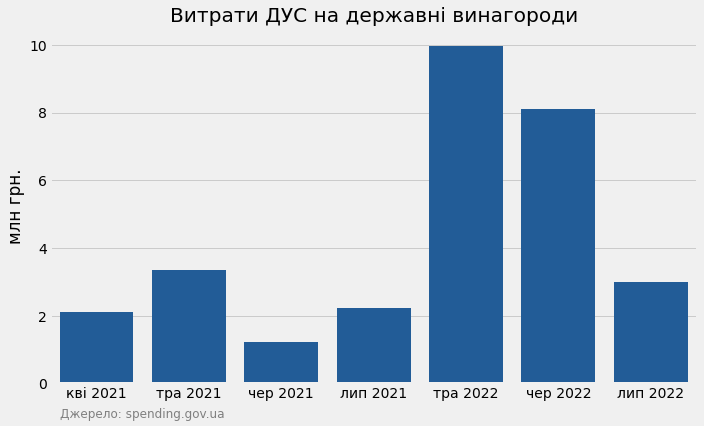

In [169]:
# years = mdates.YearLocator()   # every year
# months = mdates.MonthLocator()  # every month
# years_fmt = mdates.DateFormatter('%Y-%m')

fig, ax = plt.subplots(1, figsize=(10,6))
sns.barplot(data=award2122,
            ax=ax,
            x=award2122['date2'],
            y=award2122.amount,color="#0e5cab")

ticks_loc = ax.get_yticks().tolist()
ax.set_yticks(ax.get_yticks().tolist())
ax.set_yticklabels([int(x/1_000_000) for x in ticks_loc])

ax.set_xlabel("")
ax.set_ylim(0,10_500_000)
ax.set_ylabel("млн грн.")
ax.set_title("Витрати ДУС на державні винагороди")
ax.text(60,8,'Джерело: spending.gov.ua', transform=ax.transScale, fontsize=12,color='grey')
plt.tight_layout()
plt.savefig("4.png")